In [1]:
"""
Box plot analysis of Ksw and kA parameters from optimization results
Shows distribution of clustered optimization results for all 9 conditions
"""
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os

# Set up directories
data_dir = "./data"
output_dir = "./output"

# Define all conditions
temperatures = ['4C', '20C', '40C']
sizes = ['S', 'M', 'L']
size_labels = {'L': 'Large', 'M': 'Medium', 'S': 'Small'}

print("Box Plot Generator for Optimization Results")
print("=" * 60)

Box Plot Generator for Optimization Results


In [2]:
"""
Load optimization results from all 9 conditions
"""
print("\nLoading optimization results from all conditions...")

# Store data for box plots
ksw_data = []
ka_data = []
condition_labels = []

for temp in temperatures:
    for size in sizes:
        exp_tag = f"PPDQ_{temp}_{size}"
        
        # Load optimization specs
        spec_file = os.path.join(output_dir, f"optimization_specs_{exp_tag}.json")
        with open(spec_file, 'r') as f:
            specs = json.load(f)
        
        # Extract all Ksw and kA values from all clusters
        all_clusters = specs['all_clusters']
        ksw_values = [cluster['Ksw'] for cluster in all_clusters]
        ka_values = [cluster['kA'] for cluster in all_clusters]
        
        ksw_data.append(ksw_values)
        ka_data.append(ka_values)
        
        # Create label: temp (size_range)
        size_ranges = {'S': '90-212', 'M': '212-500', 'L': '500-1000'}
        temp_formatted = temp.replace('C', '°C')
        label = f"{temp_formatted} ({size_ranges[size]} \u03bcm)"
        condition_labels.append(label)
        
        print(f"  {exp_tag}: {len(all_clusters)} clusters")
        print(f"    Ksw range: [{min(ksw_values):.1f}, {max(ksw_values):.1f}]")
        print(f"    kA range: [{min(ka_values):.3f}, {max(ka_values):.3f}]")

print(f"\nTotal conditions loaded: {len(condition_labels)}")
print("Data ready for plotting!")


Loading optimization results from all conditions...
  PPDQ_4C_S: 100 clusters
    Ksw range: [12381.4, 26757.8]
    kA range: [224.597, 30475.539]
  PPDQ_4C_M: 100 clusters
    Ksw range: [11258.0, 43049.0]
    kA range: [75.872, 3604.922]
  PPDQ_4C_L: 100 clusters
    Ksw range: [4327.7, 23888.3]
    kA range: [44.476, 1099.761]
  PPDQ_20C_S: 100 clusters
    Ksw range: [11755.9, 20748.2]
    kA range: [264.057, 50047.893]
  PPDQ_20C_M: 100 clusters
    Ksw range: [11090.4, 26135.9]
    kA range: [138.624, 9376.852]
  PPDQ_20C_L: 100 clusters
    Ksw range: [6635.9, 24263.1]
    kA range: [66.534, 1788.204]
  PPDQ_40C_S: 100 clusters
    Ksw range: [8187.7, 12208.0]
    kA range: [403.236, 81813.070]
  PPDQ_40C_M: 100 clusters
    Ksw range: [32668.8, 43756.9]
    kA range: [472.302, 14574.214]
  PPDQ_40C_L: 100 clusters
    Ksw range: [10243.3, 28973.0]
    kA range: [95.940, 2888.309]

Total conditions loaded: 9
Data ready for plotting!



Creating box plots...


C:\Users\huan111\AppData\Local\Temp\ipykernel_21904\532897499.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(ksw_log_data, labels=condition_labels, patch_artist=True,
C:\Users\huan111\AppData\Local\Temp\ipykernel_21904\532897499.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(ka_data, labels=condition_labels, patch_artist=True,


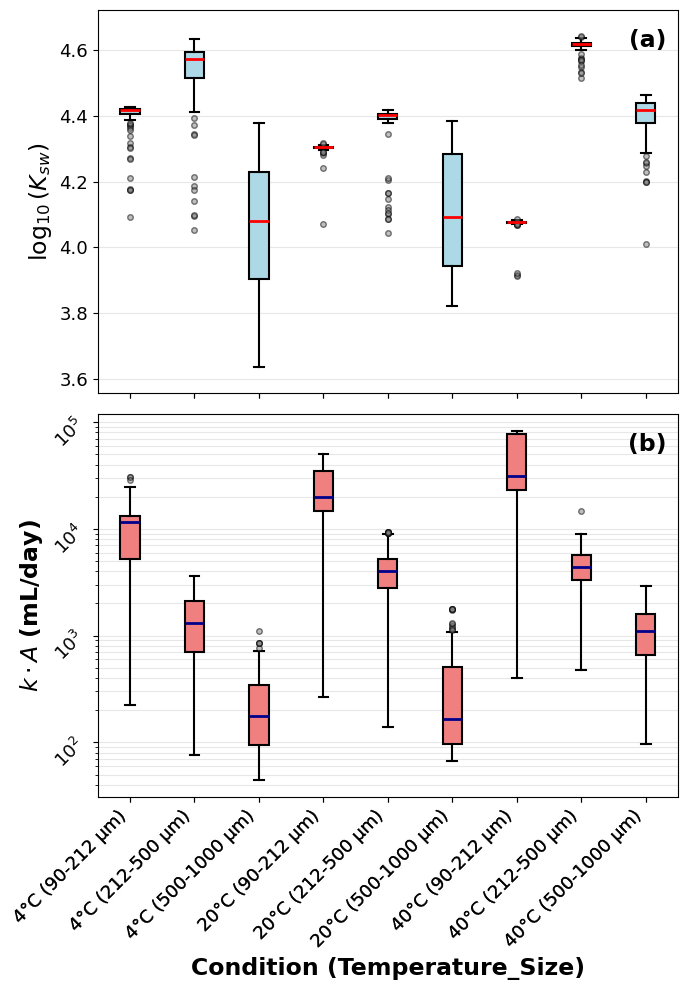


Figure saved as 'Figure_5.png'

Box plots created successfully!

Summary Statistics:

4°C (90-212 μm):
  log10(Ksw): median=4.417, Q1=4.406, Q3=4.421
  kA:  median=11613.15, Q1=5206.50, Q3=13268.80

4°C (212-500 μm):
  log10(Ksw): median=4.573, Q1=4.515, Q3=4.593
  kA:  median=1315.35, Q1=697.35, Q3=2106.67

4°C (500-1000 μm):
  log10(Ksw): median=4.079, Q1=3.904, Q3=4.231
  kA:  median=176.78, Q1=93.91, Q3=348.23

20°C (90-212 μm):
  log10(Ksw): median=4.304, Q1=4.301, Q3=4.306
  kA:  median=20002.34, Q1=14713.85, Q3=34461.69

20°C (212-500 μm):
  log10(Ksw): median=4.401, Q1=4.391, Q3=4.406
  kA:  median=4059.40, Q1=2771.68, Q3=5263.02

20°C (500-1000 μm):
  log10(Ksw): median=4.092, Q1=3.944, Q3=4.284
  kA:  median=164.65, Q1=96.46, Q3=508.35

40°C (90-212 μm):
  log10(Ksw): median=4.077, Q1=4.075, Q3=4.078
  kA:  median=31520.12, Q1=23347.67, Q3=77797.48

40°C (212-500 μm):
  log10(Ksw): median=4.618, Q1=4.611, Q3=4.622
  kA:  median=4378.79, Q1=3305.24, Q3=5680.93

40°C (500-1000

In [3]:
"""
Create box plot with two panels (upper: log10(Ksw), lower: kA)
The Ksw panel is transformed to log10(Ksw); the kA panel keeps a log-scale y-axis.
"""
print("\nCreating box plots...")

# Create figure with 2 subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 10), sharex=True)

# Upper panel: log10(Ksw)
ksw_log_data = [np.log10(np.asarray(values, dtype=float)) for values in ksw_data]
all_log_ksw = np.concatenate(ksw_log_data)
bp1 = ax1.boxplot(ksw_log_data, labels=condition_labels, patch_artist=True,
                   showfliers=True, widths=0.3)

# Customize box plot appearance for Ksw
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

for whisker in bp1['whiskers']:
    whisker.set(color='black', linewidth=1.5)

for cap in bp1['caps']:
    cap.set(color='black', linewidth=1.5)

for median in bp1['medians']:
    median.set(color='red', linewidth=2)

for flier in bp1['fliers']:
    flier.set(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)

# Ksw is already represented as log10(Ksw), so keep a linear y-axis.
log_ksw_pad = max(0.05, 0.08 * (np.nanmax(all_log_ksw) - np.nanmin(all_log_ksw)))
ax1.set_ylim(np.nanmin(all_log_ksw) - log_ksw_pad, np.nanmax(all_log_ksw) + log_ksw_pad)
ax1.set_ylabel(r'$\log_{10}(K_{sw})$', fontsize=17, fontweight='bold')
ax1.grid(True, alpha=0.3, which='major', axis='y')
ax1.tick_params(axis='y', labelsize=13)
ax1.text(0.98, 0.95, '(a)', transform=ax1.transAxes, fontsize=17, 
         fontweight='bold', va='top', ha='right')

# Lower panel: kA
bp2 = ax2.boxplot(ka_data, labels=condition_labels, patch_artist=True,
                   showfliers=True, widths=0.3)

# Customize box plot appearance for kA
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

for whisker in bp2['whiskers']:
    whisker.set(color='black', linewidth=1.5)

for cap in bp2['caps']:
    cap.set(color='black', linewidth=1.5)

for median in bp2['medians']:
    median.set(color='darkblue', linewidth=2)

for flier in bp2['fliers']:
    flier.set(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)

# Set log scale for y-axis
ax2.set_yscale('log')
ax2.set_ylabel(r'$k \cdot A$ (mL/day)', fontsize=17, fontweight='bold')
ax2.set_xlabel('Condition (Temperature_Size)', fontsize=17, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both', axis='y')
ax2.tick_params(axis='both', labelsize=13, rotation=45)
ax2.text(0.98, 0.95, '(b)', transform=ax2.transAxes, fontsize=17, 
         fontweight='bold', va='top', ha='right')

# Rotate x-axis labels for better readability
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('Figure_5.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'Figure_5.png'")
print("\nBox plots created successfully!")
print(f"\nSummary Statistics:")
print("=" * 60)

# Print summary statistics
for i, label in enumerate(condition_labels):
    ksw_vals = np.array(ksw_data[i])
    ka_vals = np.array(ka_data[i])
    ksw_log_vals = np.log10(ksw_vals)
    
    print(f"\n{label}:")
    print(f"  log10(Ksw): median={np.median(ksw_log_vals):.3f}, "
          f"Q1={np.percentile(ksw_log_vals, 25):.3f}, "
          f"Q3={np.percentile(ksw_log_vals, 75):.3f}")
    print(f"  kA:  median={np.median(ka_vals):.2f}, "
          f"Q1={np.percentile(ka_vals, 25):.2f}, "
          f"Q3={np.percentile(ka_vals, 75):.2f}")

In [4]:
"""
Cumulative analysis of K_sw from all 9 experiments
Output the paper-facing median and interquartile range without plotting.
"""
print("\n" + "=" * 60)
print("CUMULATIVE K_SW STATISTICS FROM ALL 9 EXPERIMENTS")
print("=" * 60)

# Combine all K_sw values from all conditions.
all_ksw = np.concatenate([np.asarray(values, dtype=float) for values in ksw_data])

median_ksw = np.median(all_ksw)
q1_ksw = np.percentile(all_ksw, 25)
q3_ksw = np.percentile(all_ksw, 75)
iqr_ksw = q3_ksw - q1_ksw

log_all_ksw = np.log10(all_ksw)
median_log_ksw = np.median(log_all_ksw)
q1_log_ksw = np.percentile(log_all_ksw, 25)
q3_log_ksw = np.percentile(log_all_ksw, 75)

print(f"Number of K_sw values: {len(all_ksw)}")
print("\nPaper-ready K_sw summary:")
print(f"  K_sw = {median_ksw:.2e} ({q1_ksw:.2e}-{q3_ksw:.2e})")
print(f"  IQR = {iqr_ksw:.2e}")

print("\nEquivalent log10(K_sw) summary:")
print(f"  log10(K_sw) = {median_log_ksw:.3f} ({q1_log_ksw:.3f}-{q3_log_ksw:.3f})")
print("=" * 60)



CUMULATIVE K_SW STATISTICS FROM ALL 9 EXPERIMENTS
Number of K_sw values: 900

Paper-ready K_sw summary:
  K_sw = 2.34e+04 (1.38e+04-2.71e+04)
  IQR = 1.33e+04

Equivalent log10(K_sw) summary:
  log10(K_sw) = 4.369 (4.140-4.433)
